# 09. Geometric Priors II: Deformation Stability, Scale Separation, and the GDL Blueprint

This notebook continues **Chapter 3, "Geometric Priors,"** of Bronstein, Bruna, Cohen, and Veličković, starting from **§3.3 (p. 19)** and continuing through the end of the chapter, **§3.5 (p. 30)**.

The main themes are:

1. **Deformation stability:** exact symmetry is often too rigid for real data.
2. **Scale separation:** useful representations organize information across spatial/temporal scales.
3. **Coarse-graining:** local interactions can be progressively propagated to coarser domains.
4. **The Geometric Deep Learning Blueprint:** local equivariant maps + nonlinearities + coarsening + global invariance.

We deliberately do **not** re-derive concepts already developed in earlier notebooks:

- group theory, group actions, representations, invariance, equivariance → `02_groups.ipynb`;
- vector spaces, inner products, norms, metrics, operators → `03_linear_spaces.ipynb`;
- functional analysis → `06_functional_analysis.ipynb`;
- Fourier analysis and convolution operators → `07_fourier_analysis.ipynb`;
- wavelets, multiscale localization, and deformation stability of wavelet representations → `08_wavelets_and_multiscale_signal_processing.ipynb`.

Instead, we ask:

> **How do these ingredients fit together into a geometric principle for deep architectures?**

A particular emphasis is placed on the connection between **coarse-graining in deep learning and coarse-graining in statistical physics**, mentioned on p. 26 of the proto-book.

## 1. From exact symmetry to deformation stability

The symmetry framework developed earlier assumes that we know a group $G$ of transformations that are **exact symmetries**.

For example, if translation is an exact symmetry, an invariant function satisfies

$$
f(\rho(g)x)=f(x),
\qquad g\in G.
$$

Real data are rarely this ideal. Objects deform, different parts of a scene move differently, 3D objects change shape, and graphs or manifolds can vary.

The proto-book therefore asks for a softer requirement:

> Instead of demanding invariance under a transformation that is not exactly a symmetry, require the output to change **continuously and controllably** as the transformation moves away from the symmetry group.

This is the idea of **geometric stability**.

## 2. Why small deformations do not form a symmetry group

It is tempting to say:

> If a deformation is sufficiently small, declare it a symmetry.

There is a basic obstruction. If $\tau_1$ and $\tau_2$ are each small, their composition can be substantially larger:

$$
\tau_1,\tau_2\text{ small}
\quad\not\Rightarrow\quad
\tau_1\circ\tau_2\text{ small}.
$$

Thus the set of small deformations need not be closed under composition and therefore need not form a group.

The correct language is therefore **stability**, rather than exact invariance:

$$
\boxed{\text{exact symmetry}\neq\text{small perturbation of a symmetry}.}
$$

*Interested readers can check what is a pseudogroup.*

### Example: independently moving objects

Suppose a video contains two objects moving with different velocities:

$$
v_1\neq v_2.
$$

No single global translation maps one frame to the next. Nevertheless, the semantic content may have changed very little.

A rigid group action is too restrictive, while declaring every possible deformation a symmetry is too permissive.

This is precisely the regime where **approximate symmetry** and **stability** become useful.

## 3. Stability to signal deformations

Suppose the domain $\Omega$ is fixed and the signal is deformed.

Let $c(\tau)$ measure how far a transformation $\tau$ is from the exact symmetry group $G$, with

$$
c(\tau)=0
\qquad\text{for}\qquad
\tau\in G.
$$

The proto-book defines geometric stability through

$$
\boxed{
\|f(\rho(\tau)x)-f(x)\|
\leq
C\,c(\tau)\,\|x\|.
}
$$

The important structure is:

$$
\text{output change}
\lesssim
\text{deformation size}.
$$

Thus geometric stability is a **quantitative relaxation of invariance**.

### Exact invariance is recovered

If $\tau\in G$, then $c(\tau)=0$, so

$$
\|f(\rho(\tau)x)-f(x)\|=0.
$$

Therefore

$$
f(\rho(\tau)x)=f(x).
$$

Hence

$$
\boxed{\text{invariance is the zero-deformation-cost case of stability}.}
$$

## Remark: From Local Symmetry to Gauge Theory

The discussion of local and approximate symmetries has a natural connection with
**gauge theory**. The two notions should not be identified, but gauge theory
provides a precise mathematical framework in which symmetry transformations
are allowed to vary from point to point.

Consider a field $\psi(x)$ with a global $U(1)$ symmetry:

$$
\psi(x)\mapsto e^{i\alpha}\psi(x),
$$

where $\alpha$ is constant over the domain.

If we promote the symmetry parameter to a function of position,

$$
\alpha=\alpha(x),
$$

we obtain a local transformation

$$
\boxed{
\psi(x)\mapsto e^{i\alpha(x)}\psi(x).
}
$$

However, the ordinary derivative is no longer covariant under this
transformation:

$$
\partial_\mu\psi
\mapsto
e^{i\alpha(x)}
\left(
\partial_\mu\psi
+
i(\partial_\mu\alpha)\psi
\right).
$$

The additional term involving $\partial_\mu\alpha$ prevents
$\partial_\mu\psi$ from transforming in the same way as $\psi$.

Gauge theory resolves this by introducing a **connection** (gauge field)
$A_\mu$ and replacing the ordinary derivative by the **covariant derivative**

$$
\boxed{
D_\mu=\partial_\mu+iA_\mu.
}
$$

With the appropriate transformation law for $A_\mu$,

$$
A_\mu
\mapsto
A_\mu-\partial_\mu\alpha,
$$

we obtain

$$
D_\mu\psi
\mapsto
e^{i\alpha(x)}D_\mu\psi.
$$

Thus the covariant derivative restores the desired local covariance.

The geometric principle is therefore:

$$
\boxed{
\text{global symmetry}
\;\longrightarrow\;
\text{local symmetry}
\;\longrightarrow\;
\text{connection}.
}
$$

In gauge theory, the connection provides the geometric structure needed to
compare fields at neighboring points when the choice of local reference frame
is allowed to vary from point to point.

This is closely related to the later appearance of **gauges** in Geometric
Deep Learning. However, the deformation-stability discussion here should not
be identified with gauge symmetry itself: deformation stability concerns
controlled sensitivity to transformations near a symmetry group, whereas
gauge theory concerns a symmetry whose transformation can vary locally over
the domain.

We will return to this more precise notion of local symmetry and local
reference frames when discussing the **gauge** setting of Geometric Deep
Learning.

## 4. A concrete deformation cost

For signals on a continuous Euclidean domain, the proto-book gives

$$
c^2(\tau)
=
\int_\Omega
\|\nabla d(u)\|^2\,du,
\qquad d(u)=\tau(u)-u.
$$

The quantity measures how much the displacement field varies across the domain. A rigid translation has constant displacement, whereas a non-rigid deformation has spatially varying displacement. The proto-book writes this deformation cost using its displacement-field convention; the equivalent interpretation is the formula above.

Writing

$$
d(u)=\tau(u)-u
$$

makes the intuition clearer: the gradient $\nabla d$ measures the local variation of the displacement field.

The proto-book relates this to the **Dirichlet energy** and uses it to quantify distance from the translation group.

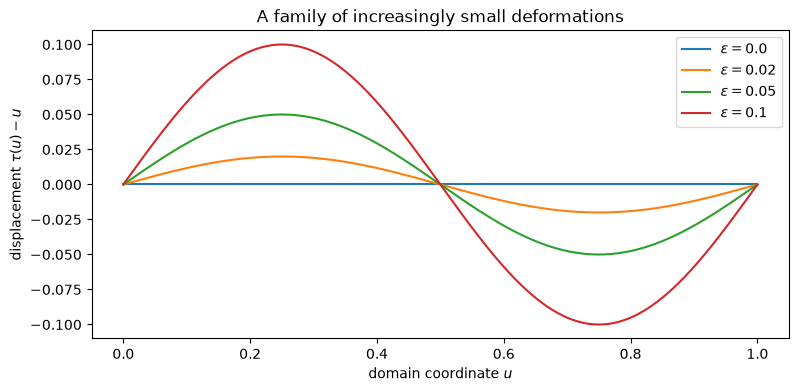

In [1]:
import numpy as np
import matplotlib.pyplot as plt

u = np.linspace(0, 1, 500)
epsilons = [0.00, 0.02, 0.05, 0.10]

plt.figure(figsize=(9, 4))

for eps in epsilons:
    displacement = eps * np.sin(2 * np.pi * u)
    plt.plot(u, displacement, label=fr"$\epsilon={eps}$")

plt.xlabel("domain coordinate $u$")
plt.ylabel("displacement $\\tau(u)-u$")
plt.title("A family of increasingly small deformations")
plt.legend()
plt.show()

For

$$
d_\epsilon(u)=\epsilon\sin(2\pi u),
$$

we have

$$
d_\epsilon'(u)=2\pi\epsilon\cos(2\pi u),
$$

so the corresponding Dirichlet energy scales as

$$
\int_0^1|d_\epsilon'(u)|^2\,du
\propto \epsilon^2.
$$

Thus the deformation becomes quantitatively small as $\epsilon\to0$.

## 5. Signal deformation versus domain deformation

There are two distinct settings.

### Signal deformation

The domain is fixed:

$$
\Omega\ \text{fixed},
\qquad
x\mapsto\rho(\tau)x.
$$

For example, an image is distorted while its pixel domain is regarded as fixed.

### Domain deformation

The geometric object itself changes:

$$
\Omega\mapsto\widetilde{\Omega}.
$$

Examples include:

- a social network whose connectivity changes;
- a graph observed at different times;
- a deforming 3D shape;
- a manifold undergoing a non-rigid deformation.

The distinction becomes crucial once the domain itself carries geometric information.

## 6. Distances between domains

Let $\mathcal D$ denote a space of possible domains. We want a distance

$$
d_{\mathcal D}(\Omega,\widetilde{\Omega})
$$

that is small when two domains are geometrically similar.

Examples in the proto-book include:

- **graph edit distance** for graphs;
- **Gromov--Hausdorff distance** for metric spaces and Riemannian manifolds.

Conceptually,

$$
\boxed{
\text{distance between points}
\longrightarrow
\text{distance between domains}.
}
$$

A common strategy is to search over alignments

$$
\eta:\Omega\to\widetilde{\Omega}
$$

that best preserve the internal structure.

### Domain stability

If $x$ lives on $\Omega$ and $\widetilde{x}$ is the corresponding aligned signal on $\widetilde{\Omega}$, the proto-book considers

$$
\boxed{
\|f(x,\Omega)-f(\widetilde{x},\widetilde{\Omega})\|
\leq
C\|x\|\,d_{\mathcal D}(\Omega,\widetilde{\Omega}).
}
$$

The exact choice of $d_{\mathcal D}$ depends on the domain.

This becomes especially important later for graphs and manifolds, where the domain itself is part of the data.

## 7. Why deformation stability is not enough

Geometric stability strengthens the global symmetry prior, but the proto-book argues that it does not by itself remove the curse of dimensionality.

Informally, there can still be too many stable functions as the domain grows.

We therefore need another source of structure:

$$
\boxed{\text{scale separation}.}
$$

The central idea is that many physical and geometric tasks can be organized hierarchically, from local/fine scales to coarse/global scales.

# Part II — Scale Separation

## 8. Fourier versus scale

Fourier analysis was developed in `07_fourier_analysis.ipynb`, and wavelets in `08_wavelets_and_multiscale_signal_processing.ipynb`.

Here we extract only the GDL lesson.

Fourier organizes information by frequency:

$$
x\longrightarrow\widehat{x}(\xi).
$$

Wavelets organize information by localized scale:

$$
x\longrightarrow(W_\psi x)(u,\xi).
$$

Fourier modes have global support, whereas wavelet atoms are localized in position and scale.

This distinction is central to why multiscale representations can be more stable under local deformations.

## 9. The GDL lesson from wavelets

A localized multiscale representation can behave approximately equivariantly under small deformations:

$$
W_\psi(\rho(\tau)x)
\approx
\rho(\tau)(W_\psi x).
$$

The key conceptual point is

$$
\boxed{\text{local equivariance}\neq\text{global invariance}.}
$$

A wavelet coefficient still remembers approximately **where** a feature occurs and **at what scale**.

To obtain a truly invariant representation, information has to be progressively aggregated toward coarser scales.

This observation is one of the bridges from wavelet analysis to deep neural architectures.

## 10. Scale separation as domain coarsening

Instead of restricting the discussion to Euclidean wavelets, consider a hierarchy of domains

$$
\Omega_0,\Omega_1,\ldots,\Omega_J,
$$

where each $\Omega_j$ is a coarser description of the previous domain.

Examples:

$$
\text{fine image}
\to
\text{coarse image}
\to
\text{coarser image},
$$

or

$$
\text{graph nodes}
\to
\text{clusters of nodes}
\to
\text{clusters of clusters}.
$$

Thus

$$
\Omega_{j+1}
$$

forgets fine-scale distinctions present in $\Omega_j$.

This is **coarse-graining**.

## 11. What does coarse-graining mean?

Suppose $u,u'\in\Omega$ are close according to a domain metric $d$.

A coarsening aggregates nearby points, schematically

$$
u\sim_j u'
\qquad\text{when}\qquad
d(u,u')\lesssim r_j.
$$

The resulting coarse domain has fewer effective degrees of freedom.

The conceptual statement is

$$
\boxed{
\text{fine-scale distinctions are compressed}
\quad\text{while}\quad
\text{larger-scale structure is retained}.
}
$$

The proto-book models this by a generally **nonlinear** coarse-graining map.

## 12. The scale-separation factorization

Let

$$
P_j:X(\Omega)\to X_j(\Omega_j)
$$

be a coarse-graining map.

The proto-book says that a function $f$ is locally stable at scale $j$ if approximately

$$
\boxed{
f\approx f_j\circ P_j,
}
$$

where

$$
f_j:X_j(\Omega_j)\to Y.
$$

The interpretation is:

> the prediction can be made after compressing the input to an appropriate scale.

This is not a claim that every function admits such a factorization. It is a **structural prior** on the functions we expect in physically and geometrically structured problems.

## 13. A simple image example

Suppose a classifier recognizes a large object in an image.

At the pixel scale there may be millions of degrees of freedom. If the label depends mainly on coarse structure, we may hope for

$$
f(x)\approx f'(Px),
$$

where

$$
P:X(\Omega)\to X(\Omega')
$$

coarsens the image.

The classifier $f'$ then operates on fewer effective degrees of freedom.

This is the idea illustrated by Figure 7 of the proto-book.

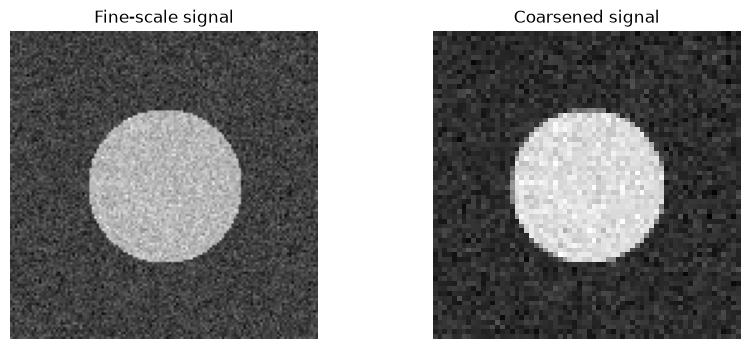

In [2]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(7)

N = 128
image = 0.15 * rng.normal(size=(N, N))

yy, xx = np.mgrid[:N, :N]
mask = (xx - N/2)**2 + (yy - N/2)**2 < (N/4)**2
image[mask] += 1.0

# Toy 2x2 average pooling.
coarse = image.reshape(N//2, 2, N//2, 2).mean(axis=(1, 3))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].imshow(image, cmap="gray")
axes[0].set_title("Fine-scale signal")
axes[0].axis("off")

axes[1].imshow(coarse, cmap="gray")
axes[1].set_title("Coarsened signal")
axes[1].axis("off")

plt.show()

The point is not that average pooling is universally optimal.

It illustrates the scale-separation hypothesis:

$$
\text{fine-scale representation}
\overset{P}{\longrightarrow}
\text{coarse-scale representation}.
$$

The coarse representation has fewer spatial degrees of freedom while retaining some large-scale structure.

# Part III — Coarse-Graining and Physics

## 14. Why the connection to physics is more than an analogy

The last paragraph of p. 26 is especially important.

Bronstein et al. explicitly connect scale separation with:

- **renormalisation group (RG)** in statistical physics;
- the **Fast Multipole Method (FMM)** in numerical analysis;
- local pooling in CNNs and GNNs.

The common structure is:

$$
\boxed{
\text{resolve local structure}
\longrightarrow
\text{aggregate it}
\longrightarrow
\text{describe larger-scale behavior}.
}
$$

This is a general multiscale principle, not merely the statement that a neural network has fewer pixels after pooling.

## 15. Real-space renormalisation: the basic idea

Consider microscopic variables

$$
s_1,s_2,\ldots,s_N.
$$

A real-space RG transformation replaces blocks of microscopic variables by collective variables:

$$
(s_1,s_2)\to S_1,
\qquad
(s_3,s_4)\to S_2,
\qquad\ldots
$$

so that

$$
\{s_i\}_{i=1}^{N}
\longrightarrow
\{S_j\}_{j=1}^{N/2}.
$$

The number of degrees of freedom decreases.

The important question is not merely

> How much information was discarded?

but

> **Which information survives because it matters at larger scales?**

This is the language of **relevant and irrelevant degrees of freedom** in RG.

## 16. A toy majority-rule coarse-graining

For an Ising configuration

$$
s_i\in\{-1,+1\},
$$

one simple coarse-graining rule is majority voting over blocks of three:

$$
(s_{3j},s_{3j+1},s_{3j+2})
\longrightarrow
S_j
=
\operatorname{sign}
(s_{3j}+s_{3j+1}+s_{3j+2}).
$$

This is a nonlinear map

$$
P_{\mathrm{RG}}:
\{-1,+1\}^N
\to
\{-1,+1\}^{N/3}.
$$

Notice the structural analogy with neural pooling:

$$
\boxed{\text{local nonlinear aggregation}+\text{resolution reduction}.}
$$

This is a toy RG transformation, **not** a claim that ordinary CNN pooling is literally a physical RG transformation.

In [3]:
def majority_coarsen(spins, block_size=3):
    # Coarsen an Ising-like configuration by majority rule.
    n = len(spins)
    n_blocks = n // block_size
    blocks = spins[:n_blocks * block_size].reshape(n_blocks, block_size)
    sums = blocks.sum(axis=1)
    return np.where(sums >= 0, 1, -1)

rng = np.random.default_rng(10)
spins = rng.choice([-1, 1], size=81)

levels = [spins]
for _ in range(3):
    levels.append(majority_coarsen(levels[-1], block_size=3))

for j, level in enumerate(levels):
    print(f"level {j}: {len(level)} degrees of freedom")

level 0: 81 degrees of freedom
level 1: 27 degrees of freedom
level 2: 9 degrees of freedom
level 3: 3 degrees of freedom


The hierarchy is

$$
81\longrightarrow27\longrightarrow9\longrightarrow3.
$$

The exact numbers are arbitrary; what matters is the structural pattern:

$$
\boxed{\text{fine degrees of freedom}\to\text{coarse collective variables}.}
$$

This is the physics intuition behind the scale hierarchy in the GDL blueprint.

## 17. Relevant versus irrelevant information

The RG perspective gives a useful interpretation of pooling.

Suppose a microscopic perturbation changes a variable at fine scale but has negligible influence on coarse variables. It is effectively **irrelevant at the coarse scale**.

Conversely, a collective pattern that survives repeated coarse-graining is **relevant**.

Thus hierarchical learning can be viewed heuristically as repeatedly asking:

$$
\boxed{\text{What information remains important after increasing the scale?}}
$$

Mehta and Schwab established a precise mapping between a variational RG procedure and a class of deep-learning architectures, while later work investigated information-preserving learned RG transformations.

## 18. Why the analogy must be used carefully

It is tempting to write

$$
\text{CNN}=\text{renormalisation group}.
$$

That is too strong.

The similarities include:

- hierarchical representations;
- local aggregation;
- reduction of degrees of freedom;
- scale-dependent features;
- the search for useful coarse variables.

But ordinary supervised deep learning is not automatically a physical RG transformation.

A safer statement is

$$
\boxed{
\text{deep architectures can implement RG-like coarse-graining principles}.
}
$$

The distinction matters because the learning objective, representation space, and coarse-graining rule can differ substantially from those of a physical RG.

## 19. The Fast Multipole Method

The proto-book also mentions the Fast Multipole Method.

In a long-range interaction problem, many nearby sources can be grouped and represented collectively:

$$
\{\text{many nearby sources}\}
\longrightarrow
\{\text{one effective coarse representation}\}.
$$

A distant observer can then interact with the coarse representation rather than with every microscopic source separately.

Thus FMM shares the structural principle

$$
\boxed{
\text{local grouping}
\to
\text{effective coarse description}
\to
\text{efficient long-range computation}.
}
$$

This shows that hierarchical coarse-graining is a broad computational idea, not something invented for deep learning.

# Part IV — From Scale Separation to Deep Networks

## 20. Why linear invariant maps are too weak

Suppose

$$
f:X(\Omega)\to Y
$$

is both linear and $G$-invariant.

Averaging over the group gives

$$
f(x)
=
f\left(
\frac{1}{\mu(G)}
\int_G \rho(g)x\,d\mu(g)
\right).
$$

Thus $f$ depends on $x$ only through its group average.

For translations of an image, this can be as crude as retaining only global average RGB information.

Therefore

$$
\boxed{\text{linear invariance alone is not expressive enough}.}
$$

This is why the blueprint requires **nonlinearity**.

## 21. Equivariance first, nonlinearity second

Suppose

$$
B:X(\Omega,C)\to X(\Omega,C')
$$

is $G$-equivariant:

$$
B(g.x)=g.B(x).
$$

Let

$$
\sigma:C'\to C''
$$

be a pointwise nonlinearity:

$$
(\sigma(x))(u)=\sigma(x(u)).
$$

Then

$$
\sigma(g.x)=g.\sigma(x),
$$

so

$$
U=\sigma\circ B
$$

is again equivariant:

$$
U(g.x)=g.U(x).
$$

The important architectural principle is therefore:

$$
\boxed{
\text{equivariant linear/local operation}
\to
\text{pointwise nonlinearity}
\to
\text{equivariant feature map}.
}
$$

We already developed equivariance itself in `02_groups.ipynb`; the new point here is its role as a compositional architecture-building rule.

## 22. A toy equivariant operator

On a one-dimensional periodic grid, consider

$$
(Bx)_i
=
\sum_k\theta_kx_{i-k}.
$$

For a cyclic shift $S$,

$$
B(Sx)=S(Bx).
$$

If $\sigma$ is pointwise, then

$$
\sigma(Sx)=S(\sigma(x)).
$$

Hence

$$
\sigma\circ B
$$

remains shift-equivariant.

We verify this numerically without implementing a complete CNN.

In [4]:
def periodic_convolution(x, kernel):
    out = np.zeros_like(x, dtype=float)
    center = len(kernel) // 2

    for i in range(len(x)):
        for k, weight in enumerate(kernel):
            offset = k - center
            out[i] += weight * x[(i - offset) % len(x)]

    return out

def cyclic_shift(x, amount):
    return np.roll(x, amount)

def relu(x):
    return np.maximum(x, 0.0)

x = np.array([0., 1., 2., 4., 1., 0., 3., 2.])
theta = np.array([1., -0.5, 0.25])
shift = 2

left = periodic_convolution(cyclic_shift(x, shift), theta)
right = cyclic_shift(periodic_convolution(x, theta), shift)

print("Equivariance error:", np.linalg.norm(left - right))

Equivariance error: 0.0


In [5]:
left = relu(periodic_convolution(cyclic_shift(x, shift), theta))
right = cyclic_shift(relu(periodic_convolution(x, theta)), shift)

print("Equivariance error after nonlinearity:",
      np.linalg.norm(left - right))

Equivariance error after nonlinearity: 0.0


## 23. Local equivariance and receptive fields

The blueprint asks for **local equivariant maps**.

If $U$ is local, then

$$
(Ux)(u)
$$

depends only on

$$
N_u=\{v:d(u,v)\le r\}.
$$

The set $N_u$ is the **receptive field**.

The important GDL point is that locality is defined by the geometry of the domain:

- grid → spatial neighborhood;
- graph → graph neighborhood;
- manifold → geodesic neighborhood.

Thus

$$
\boxed{\text{locality is geometric, not necessarily Euclidean}.}
$$

## 24. Why depth creates long-range interactions

A single local layer cannot represent an arbitrary function involving distant points.

But compose local maps:

$$
U_J\circ U_{J-1}\circ\cdots\circ U_1.
$$

The receptive field grows.

Schematically,

$$
r\to 2r\to3r\to\cdots
$$

for a simple architecture.

Thus depth allows information to propagate over large distances while every individual operation remains local and equivariant.

This gives a geometric interpretation of deep composition.

In [6]:
# A simple receptive-field illustration.
# Each layer expands the 1D receptive field by one site on each side.

receptive_field = 1

for depth in range(1, 6):
    receptive_field += 2
    print(f"after {depth} local layers: receptive field = {receptive_field}")

after 1 local layers: receptive field = 3
after 2 local layers: receptive field = 5
after 3 local layers: receptive field = 7
after 4 local layers: receptive field = 9
after 5 local layers: receptive field = 11


## 25. Coarsening increases receptive fields faster

Insert a coarsening operator between local layers.

One coarse coordinate can represent a whole neighborhood of the fine domain. A subsequent local operation on the coarse domain therefore covers a much larger region of the original domain.

Hence

$$
\boxed{
\text{local composition}+\text{coarsening}
\Rightarrow
\text{rapid growth of receptive field}.
}
$$

The proto-book explicitly connects this mechanism to **Multiresolution Analysis (MRA)**.

# Part V — The Geometric Deep Learning Blueprint

## 26. The building blocks

The geometric blueprint has four operational ingredients:

### (i) Linear equivariant layer

$$
B:X(\Omega,C)\to X(\Omega',C')
$$

with

$$
B(g.x)=g.B(x).
$$

### (ii) Pointwise nonlinearity

$$
\sigma:C'\to C''.
$$

### (iii) Local pooling / coarsening

$$
P:X(\Omega,C)\to X(\Omega',C).
$$

### (iv) Global invariant layer

$$
A:X(\Omega,C)\to Y
$$

with

$$
A(g.x)=A(x).
$$

Thus:

$$
\boxed{
\text{local equivariance}
+
\text{nonlinearity}
+
\text{coarsening}
+
\text{global invariance}.
}
$$

This is the central architectural message of §3.5.

## 27. The abstract blueprint

The proto-book writes a general invariant architecture as

$$
f
=
A
\circ
\sigma_J
\circ
B_J
\circ
P_{J-1}
\circ
\cdots
\circ
P_1
\circ
\sigma_1
\circ
B_1.
$$

The spaces must match from one block to the next.

This is **not one particular neural-network architecture**.

It is a structural template. Different choices of:

- domain $\Omega$;
- symmetry group $G$;
- equivariant map $B$;
- nonlinearity $\sigma$;
- coarsening $P$;
- invariant readout $A$

produce different geometric architectures.

## 28. Why the architecture becomes deep

There is a useful chain:

$$
\boxed{
\begin{aligned}
\text{locality}
&\Rightarrow \text{small receptive fields},\\
\text{composition}
&\Rightarrow \text{larger receptive fields},\\
\text{coarsening}
&\Rightarrow \text{faster access to large scales},\\
\text{global pooling}
&\Rightarrow \text{invariance}.
\end{aligned}}
$$

Thus depth has a geometric interpretation:

> information moves from local structure to increasingly global structure while respecting the symmetries of the domain.

## 29. The graph version of the blueprint

Figure 8 in the proto-book gives the blueprint on a graph:

$$
\boxed{
\text{equivariant layer}
\rightarrow
\text{local pooling}
\rightarrow
\text{equivariant layer}
\rightarrow
\text{global invariant pooling}.
}
$$

For a graph, the relevant symmetry is typically a permutation of node labels.

The local equivariant layers compute node features while respecting that symmetry. Local pooling coarsens the graph. Global pooling produces a graph-level invariant.

We will study the actual GNN constructions later; here the goal is to understand **why the architecture has this form**.

## 30. Fixed versus varying domains

The proto-book distinguishes:

### Fixed domain

$$
\Omega=\text{fixed}.
$$

Only the signal varies. Standard image classification is the canonical example.

### Varying domain

The input is

$$
(\Omega,x).
$$

Graph classification is the canonical example because both graph structure and node/edge features matter.

For varying domains, stability with respect to deformations of $\Omega$ becomes especially important.

## 31. The architecture table as a geometric dictionary

The proto-book's table can be read as:

| Architecture | Domain $\Omega$ | Symmetry |
|---|---|---|
| CNN | grid | translation |
| Spherical CNN | sphere / $SO(3)$ | rotation |
| Intrinsic / Mesh CNN | manifold | isometry / gauge symmetry |
| GNN | graph | permutation |
| Deep Sets | set | permutation |
| Transformer | complete graph | permutation |
| LSTM | 1D grid | time warping |

The point is not to memorize the table.

For any architecture, ask:

$$
\boxed{
\text{What is the domain?}
\quad
\text{What is the symmetry?}
\quad
\text{How is scale handled?}
}
$$

Then ask how local equivariance and global invariance are implemented.

# Part VI — A Toy End-to-End Blueprint

## 32. A one-dimensional architecture

We now build a deliberately simple model containing all the conceptual ingredients:

$$
\boxed{
\text{local equivariant map}
\rightarrow
\text{nonlinearity}
\rightarrow
\text{coarsening}
\rightarrow
\text{local equivariant map}
\rightarrow
\text{global invariant}.
}
$$

This is not a practical CNN. It is a computational diagram of the blueprint.

In [7]:
def local_layer(x, kernel):
    return relu(periodic_convolution(x, kernel))

def average_pool_2(x):
    n = len(x)
    x = x[:n - n % 2]
    return x.reshape(-1, 2).mean(axis=1)

def global_average(x):
    return np.mean(x)

rng = np.random.default_rng(3)
x = rng.normal(size=32)

kernel_1 = np.array([0.2, 1.0, -0.3])
kernel_2 = np.array([-0.4, 0.7, 0.1])

h1 = local_layer(x, kernel_1)
h2 = average_pool_2(h1)
h3 = local_layer(h2, kernel_2)
y = global_average(h3)

print("input size:", len(x))
print("after first local layer:", len(h1))
print("after coarsening:", len(h2))
print("after second local layer:", len(h3))
print("global output:", y)

input size: 32
after first local layer: 32
after coarsening: 16
after second local layer: 16
global output: 0.24352579451772965


## 33. Testing the geometric structure

For a cyclic shift $S$,

$$
B(Sx)=S(Bx)
$$

should hold for the local equivariant layer.

The global average satisfies

$$
A(Sx)=A(x).
$$

Coarsening is subtler: a pooling operator is not automatically equivariant or invariant with respect to every transformation. Its symmetry must be compatible with the transformation and with the induced action on the coarse domain.

This is an important practical warning:

> **Pooling must be designed together with the symmetry and geometry of the domain.**

In [8]:
shift = 5

equivariance_error = np.linalg.norm(
    local_layer(np.roll(x, shift), kernel_1)
    - np.roll(local_layer(x, kernel_1), shift)
)

print("local equivariance error:", equivariance_error)

invariance_error = abs(
    global_average(local_layer(x, kernel_1))
    - global_average(local_layer(np.roll(x, shift), kernel_1))
)

print("global invariance error:", invariance_error)

local equivariance error: 0.0
global invariance error: 0.0


The experiment separates two roles:

$$
\boxed{
\begin{aligned}
\text{equivariance} &: \text{preserve geometric information},\\
\text{invariance} &: \text{discard irrelevant global transformations}.
\end{aligned}}
$$

The blueprint needs both, but **at different stages**.

# Part VII — Examples and Non-Examples

## 34. Examples

### Image classification

- domain: pixel grid;
- symmetry: translation;
- local equivariant operation: convolution;
- coarsening: pooling or strided representation;
- global invariant: global pooling/readout.

### Graph classification

- domain: graph;
- symmetry: node permutations;
- local equivariant operation: message passing;
- coarsening: graph pooling;
- global invariant: permutation-invariant readout.

### Molecular property prediction

- domain: molecular graph or geometric point set;
- symmetry: permutation symmetry, often together with Euclidean symmetries;
- local operation: neighborhood interactions;
- coarsening: hierarchical representation;
- readout: molecule-level invariant.

## 35. Non-examples and failure modes

### A generic MLP on pixels

A fully connected network can approximate functions on a flattened image, but it does not automatically encode translation equivariance.

### Global averaging as the entire representation

Global averaging is invariant, but it destroys spatial organization:

$$
\text{invariance}\not\Rightarrow\text{useful representation}.
$$

### Declaring every deformation a symmetry

Using the full diffeomorphism group as an exact symmetry can identify inputs whose semantic content has genuinely changed:

$$
\text{more symmetry}\not\Rightarrow\text{better model}.
$$

The symmetry group must reflect the task.

# Part VIII — Connection with Patrick Nicolas' Primer

Patrick Nicolas' **"A Friendly Primer on Geometric Deep Learning"** is useful as a complementary, less formal overview.

The article emphasizes symmetry as the organizing principle of GDL and surveys graphs, meshes, manifolds, topological learning, and information-geometric learning. It is intentionally less rigorous than the mathematical treatment in the Bronstein et al. proto-book, so here it is used as a conceptual companion rather than as the primary mathematical source.

A useful way to read the two together is:

$$
\boxed{
\text{Bronstein et al.}
\rightarrow
\text{formal geometric blueprint}
}
$$

while

$$
\boxed{
\text{Nicolas}
\rightarrow
\text{broader conceptual map of GDL}.
}
$$

# Part IX — The Big Picture

## 36. Three geometric priors

Chapter 3 can be compressed into three principles.

### 1. Symmetry

Use exact invariance/equivariance when the transformation is genuinely a symmetry.

$$
f(\rho(g)x)=f(x)
$$

or

$$
f(\rho(g)x)=\rho'(g)f(x).
$$

### 2. Geometric stability

When transformations are only approximately symmetric, require controlled sensitivity:

$$
\|f(\rho(\tau)x)-f(x)\|
\lesssim
c(\tau)\|x\|.
$$

### 3. Scale separation

Organize the representation through progressively coarser domains:

$$
X(\Omega)
\overset{P_1}{\longrightarrow}
X(\Omega_1)
\overset{P_2}{\longrightarrow}
\cdots
\overset{P_J}{\longrightarrow}
X(\Omega_J).
$$

Together these provide the geometric constraints motivating the blueprint.

## 37. The central conceptual diagram

The whole notebook can be summarized as

$$
\boxed{
\begin{array}{c}
\text{domain geometry}\\
\downarrow\\
\text{symmetry group}\\
\downarrow\\
\text{local equivariant maps}\\
\downarrow\\
\text{nonlinearity}\\
\downarrow\\
\text{coarsening / scale separation}\\
\downarrow\\
\text{larger receptive fields}\\
\downarrow\\
\text{global invariant readout}
\end{array}}
$$

The architecture is not chosen first and justified afterward.

Rather:

$$
\boxed{
\text{geometry}
\longrightarrow
\text{inductive bias}
\longrightarrow
\text{architectural building blocks}.
}
$$

## 38. Physics perspective

The coarse-graining discussion suggests a second chain:

$$
\boxed{
\text{microscopic degrees of freedom}
\longrightarrow
\text{local aggregation}
\longrightarrow
\text{coarse variables}
\longrightarrow
\text{effective large-scale description}.
}
$$

This appears in:

- renormalisation group;
- multiresolution analysis;
- wavelet decompositions;
- fast multipole methods;
- pooling in deep networks.

The mathematical details differ, but the **multiscale organizational principle** is shared.

## 39. What changes when we move to graphs?

The blueprint does not disappear when the grid disappears.

Instead, we replace Euclidean neighborhoods by a domain-appropriate notion of neighborhood.

For a graph,

$$
N_u=\{v:d_G(u,v)\le r\},
$$

where $d_G$ is a graph distance.

Then:

- local equivariance becomes permutation equivariance;
- local receptive fields become graph neighborhoods;
- pooling becomes graph coarsening;
- global pooling becomes permutation invariance.

This is why the blueprint is useful: it separates the **geometric principle** from its particular implementation.

The actual GNN constructions will come later.

# 40. Exercises

### Exercise 1 — Stability

Suppose

$$
\|f(\rho(\tau)x)-f(x)\|
\le Cc(\tau)\|x\|.
$$

Explain precisely why $G$-invariance is recovered whenever $c(\tau)=0$ for $\tau\in G$.

### Exercise 2 — Small deformations

Construct two transformations that are each small perturbations of the identity but whose composition is noticeably larger. Explain the failure of closure.

### Exercise 3 — Coarse-graining

For a $2^J\times2^J$ image, suppose every pooling step replaces each $2\times2$ block by one coarse pixel. How many spatial sites remain after $j$ pooling steps?

### Exercise 4 — Receptive fields

For a 1D network with kernel size $3$, stride $1$, and no pooling, compute the receptive-field size after $J$ layers. Then repeat with factor-$2$ pooling after every second layer.

### Exercise 5 — RG analogy

For

$$
(s_1,s_2,s_3)\mapsto\operatorname{sign}(s_1+s_2+s_3),
$$

construct two microscopic configurations that become identical after one coarse-graining step. What information was discarded?

### Exercise 6 — Linear invariance

For a finite group $G$, prove

$$
f(x)=f\left(
\frac1{|G|}\sum_{g\in G}g.x
\right)
$$

when $f$ is linear and invariant. Why can this be restrictive?

### Exercise 7 — Architecture identification

For image classification, node classification, graph classification, and set classification, identify:

1. the domain;
2. the symmetry group;
3. the local equivariant operation;
4. the coarsening operation;
5. the global invariant operation.

### Exercise 8 — Critical thinking

Is every pooling operation a valid coarse-graining in the sense of the GDL blueprint? What properties should a geometrically meaningful coarsening map satisfy?

# 41. Summary

The main lessons of §3.3–§3.5 are:

1. **Exact symmetries are idealisations.** Real data often exhibit approximate symmetries and deformations.
2. **Stability replaces exact invariance** when transformations are near, but not inside, the symmetry group.
3. **Signal deformation and domain deformation are different problems.**
4. **Scale separation** organizes information from local/fine scales to coarse/global scales.
5. A coarse-graining map

$$
P_j:X(\Omega)\to X_j(\Omega_j)
$$

allows a locally stable target to approximately factor as

$$
f\approx f_j\circ P_j.
$$

6. This has deep connections with **renormalisation-group coarse-graining** and other multiscale numerical methods.
7. **Linear invariants are too restrictive** to provide rich representations by themselves.
8. Local equivariant maps followed by nonlinearities preserve equivariance.
9. Composition enlarges receptive fields while preserving local geometric structure.
10. Coarsening accelerates propagation of information to larger scales.
11. The blueprint consists of

$$
\boxed{
\text{local equivariant maps}
+
\text{nonlinearities}
+
\text{coarsening}
+
\text{global invariant readout}.
}
$$

12. Different GDL architectures arise by changing the domain, symmetry group, and implementations of these blocks.

The deepest conceptual message is:

$$
\boxed{
\text{geometry}
\;\longrightarrow\;
\text{inductive bias}
\;\longrightarrow\;
\text{architecture}.
}
$$

# References

### Primary source

1. M. M. Bronstein, J. Bruna, T. Cohen, P. Veličković, **Geometric Deep Learning: Grids, Groups, Graphs, Geodesics, and Gauges**, 2021.  
   arXiv:2104.13478. Sections 3.3–3.5, pp. 19–30.

### Complementary GDL overview

2. Patrick R. Nicolas, **A Friendly Primer on Geometric Deep Learning**, 2025.  
   https://patricknicolas.substack.com/p/a-friendly-primer-on-geometric-deep

### Multiscale and wavelet analysis

3. S. Mallat, **A Wavelet Tour of Signal Processing: The Sparse Way**, 3rd ed., Academic Press, 2009.

4. S. Mallat, **A theory for multiresolution signal decomposition: the wavelet representation**, IEEE TPAMI 11 (1989), 674–693.

### Renormalisation group and deep learning

5. P. Mehta and D. J. Schwab, **An exact mapping between the variational renormalization group and deep learning**, arXiv:1410.3831 (2014).

6. C. Bény, **Deep learning and the renormalization group**, arXiv:1301.3124 (2013).

7. M. Koch-Janusz and Z. Ringel, **Mutual information, neural networks and the renormalization group**, Nature Physics 14 (2018), 578–581.

### Earlier notebooks in this repository

- `02_groups.ipynb`
- `03_linear_spaces.ipynb`
- `06_functional_analysis.ipynb`
- `07_fourier_analysis.ipynb`
- `08_wavelets_and_multiscale_signal_processing.ipynb`